This notebook trains a Random Forest Regressor to predict the next-day closing price of Bitcoin (BTC-USD) using features engineered from historical OHLCV (Open, High, Low, Close, Volume) data — including rolling averages and price ratios across multiple time horizons. Hyperparameters (number of trees, max depth, etc.) are tuned with RandomizedSearchCV using time-series cross-validation and feature importances and residuals are visualized to assess model behavior.

In [1]:
import yfinance as yf
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle

#Retrieving the data

In [2]:
btc_ticker = yf.Ticker("BTC-USD")
if os.path.exists("btc.csv"):
    btc = pd.read_csv("btc.csv", index_col=0)
else:
    btc = btc_ticker.history(start="2014-09-17", end="2024-09-01")
    btc.to_csv("btc.csv")

#Data preprocessing

In [3]:
# Preprocess the data
btc = btc.drop(columns=["Dividends", "Stock Splits"])
btc.index = pd.to_datetime(btc.index)
btc.index = btc.index.tz_localize(None)

#Feature engineering

In [4]:
def compute_rolling(btc):
    horizons = [2,7,60,365]

    for horizon in horizons:
        rolling_averages = btc.rolling(horizon, min_periods=1).mean()

        ratio_column = f"open_ratio_{horizon}"
        btc[ratio_column] = btc["Open"] / rolling_averages["Open"]

        rolling = btc.rolling(horizon, closed='left', min_periods=1).mean()
        trend_column = f"trend_{horizon}"
        btc[trend_column] = rolling["Open"]

        btc = btc.dropna()

    return btc

In [5]:
btc = compute_rolling(btc)

/tmp/ipykernel_373/1502108625.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc[ratio_column] = btc["Open"] / rolling_averages["Open"]
/tmp/ipykernel_373/1502108625.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc[trend_column] = rolling["Open"]


#Splitting the data

In [6]:
# btc.fillna(method='ffill', inplace=True)

In [7]:
# btc = compute_rolling(btc)

# X = btc.drop(columns=['Close'])
# y = btc['Close']

# # Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, shuffle=False)

In [8]:
# X_train

In [9]:
# y_train_index = y_train.index
# y_train_index

In [10]:
# X_test

#Normalizing the features

In [11]:
# # Normalize the features
# scaler = MinMaxScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [12]:
# Define the features and target
btc_features = ['Open', 'High', 'Low', 'Volume', 'open_ratio_2', 'trend_2', 'open_ratio_7', 'trend_7', 'open_ratio_60', 'trend_60', 'open_ratio_365', 'trend_365']
X = btc[btc_features]
y = btc['Close']

In [13]:
# Normalize the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
# Split the data into training and testing sets
train_len = int(len(X) * 0.8)
# test_size = len(X) - train_len
X_train, X_test = X_scaled[0:train_len], X_scaled[train_len:len(X)]
y_train, y_test = y[0:train_len], y[train_len:len(X)]

In [15]:
y_test_index = y_test.index

#Hyperparameter tuning and finding the best model

In [16]:
# Define the parameter grid for GridSearchCV
parameters = {
    'n_estimators': [50, 100, 200, 300],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the RandomForestRegressor
rf = RandomForestRegressor(random_state=1)

# Initialize TimeSeriesSplit with the number of splits
tscv = TimeSeriesSplit(n_splits=3)

# Use RandomizedSearchCV for faster parameter tuning
random_search = RandomizedSearchCV(estimator=rf, param_distributions=parameters, n_iter=100, cv=tscv,
                                   n_jobs=-1, verbose=1, scoring='neg_mean_squared_error', random_state=1)

# Fit the model to the training data

random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_

# Predict on the test set to check the model's performance
y_pred = best_rf.predict(X_test)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


In [17]:
# Get all parameters of the best model
best_rf_params = best_rf.get_params()
print("All Parameters of Best Random Forest Model:", best_rf_params)


All Parameters of Best Random Forest Model: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 50, 'n_jobs': None, 'oob_score': False, 'random_state': 1, 'verbose': 0, 'warm_start': False}


#Model evaluation

In [18]:
# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred)
mse_rf = mean_squared_error(y_test, y_pred)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred)

print(f"RFR - Mean Absolute Error: {mae_rf}")
print(f"RFR - Mean Squared Error: {mse_rf}")
print(f"RFR - Root Mean Squared Error: {rmse_rf}")
print(f"RFR - R-squared: {r2_rf}")

RFR - Mean Absolute Error: 719.1426386243222
RFR - Mean Squared Error: 1652170.1258372643
RFR - Root Mean Squared Error: 1285.3677006356058
RFR - R-squared: 0.994713963234362


#Scaled metrics for plotting

In [19]:
# Reshape y_test and y_pred to 2D arrays for the scaler
y_test_reshaped = np.array(y_test).reshape(-1, 1)
y_pred_reshaped = np.array(y_pred).reshape(-1, 1)

# Min-Max scale y_test and y_pred
scaler = StandardScaler()
y_test_scaled = scaler.fit_transform(y_test_reshaped)
y_pred_scaled = scaler.transform(y_pred_reshaped)

# Calculate the metrics on the scaled data
mae_scaled_rf = mean_absolute_error(y_test_scaled, y_pred_scaled)
mse_scaled_rf = mean_squared_error(y_test_scaled, y_pred_scaled)
rmse_scaled_rf = np.sqrt(mse_scaled_rf)
r2_scaled_rf = r2_score(y_test_scaled, y_pred_scaled)

print(f"RFR - Scaled Mean Absolute Error: {mae_scaled_rf}")
print(f"RFR - Scaled Mean Squared Error: {mse_scaled_rf}")
print(f"RFR - Scaled Root Mean Squared Error: {rmse_scaled_rf}")
print(f"RFR - Scaled R-squared: {r2_scaled_rf}")

RFR - Scaled Mean Absolute Error: 0.04067735881719631
RFR - Scaled Mean Squared Error: 0.0052860367656380235
RFR - Scaled Root Mean Squared Error: 0.07270513575833569
RFR - Scaled R-squared: 0.994713963234362


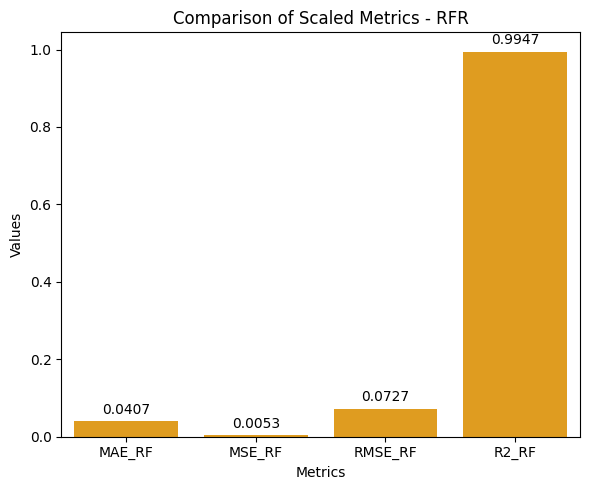

In [20]:
# Prepare data for plotting
metrics = ['MAE_RF', 'MSE_RF', 'RMSE_RF', 'R2_RF']
scaled_values = [mae_scaled_rf, mse_scaled_rf, rmse_scaled_rf, r2_scaled_rf]

# Create a DataFrame for better visualization with Seaborn
metrics_df = pd.DataFrame({'Metric': metrics, 'Value': scaled_values})

# Plotting the scaled metrics using seaborn
plt.figure(figsize=(6, 5))
sns.barplot(x='Metric', y='Value', data=metrics_df, color="orange")

# Add some text for labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Comparison of Scaled Metrics - RFR')

# Function to label the bars
def autolabel(rects, ax):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 4)),  # rounded to 4 decimal places for better precision
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# Get the current Axes instance
ax = plt.gca()

# Apply the autolabel function
rects = ax.patches
autolabel(rects, ax)

plt.tight_layout()
plt.show()

#Plotting the predicted vs true closing values

Date
2022-09-05    19832.110670
2022-09-06    19618.153404
2022-09-07    19208.916950
2022-09-08    19361.453265
2022-09-09    21061.074316
                  ...     
2024-08-27    60820.251307
2024-08-28    59004.997610
2024-08-29    59887.437312
2024-08-30    58989.768074
2024-08-31    59081.219653
Length: 727, dtype: float64


Text(0.5, 0, 'Date')

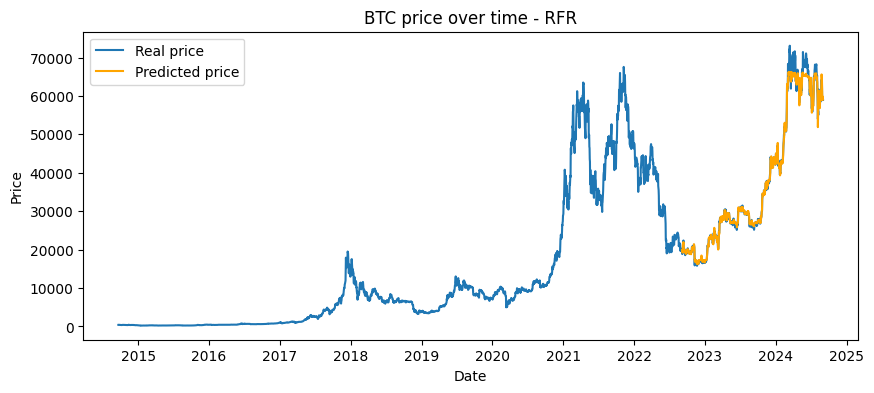

In [21]:
y_pred = pd.Series(y_pred, index=y_test.index)
# y_pred = y_pred.sort_index()
print(y_pred)

plt.figure(figsize=(10,4))

# Add title
plt.title("BTC price over time - RFR")

# Line chart
sns.lineplot(data=btc["Close"], label="Real price")

# Line chart
sns.lineplot(data=y_pred, label="Predicted price", color="orange")

# Add legend
plt.legend()

# Add label for vertical axis
plt.ylabel("Price")

# Add label for horizontal axis
plt.xlabel("Date")

#Plotting the residuals

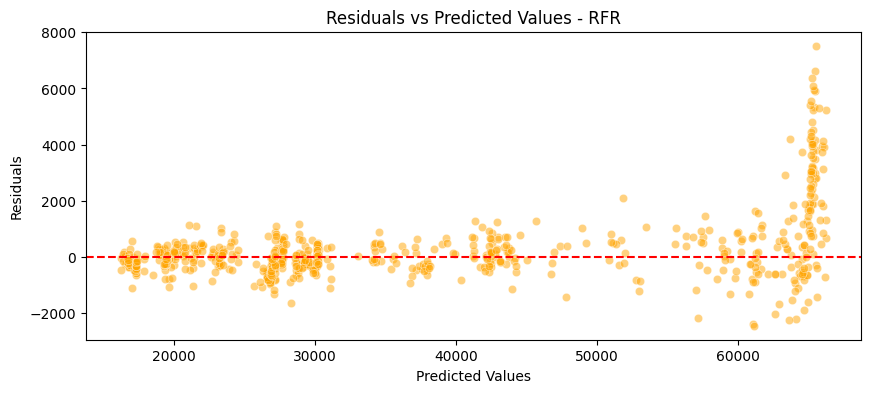

In [22]:
# Calculate residuals
residuals = y_test - y_pred

# Plot residuals using seaborn
plt.figure(figsize=(10, 4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color="orange")
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Values - RFR')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

#Plotting feature importance

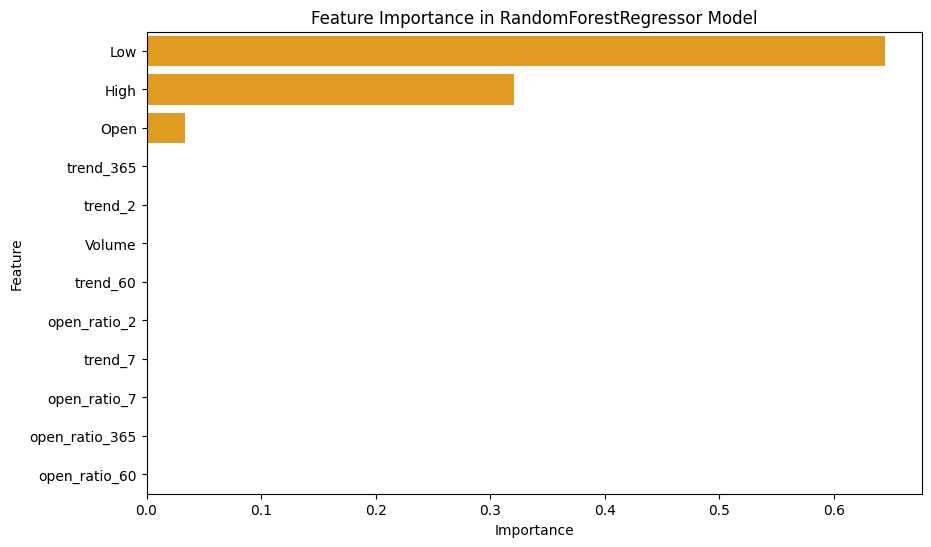

In [23]:
# Get feature importances from the best model
importances = best_rf.feature_importances_

# Create a DataFrame for better visualization
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, color="orange")
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in RandomForestRegressor Model')
plt.show()

In [24]:
compare = pd.DataFrame({'y_test': y_test, 'y_pred_rf': y_pred}, index=y_test_index)
compare

,y_test,y_pred_rf
Date,,
2022-09-05,19812.371094,19832.110670
2022-09-06,18837.667969,19618.153404
2022-09-07,19290.324219,19208.916950
2022-09-08,19329.833984,19361.453265
2022-09-09,21381.152344,21061.074316
...,...,...
2024-08-27,59504.132812,60820.251307
2024-08-28,59027.625000,59004.997610
2024-08-29,59388.179688,59887.437312


In [25]:
# Save the Series to files

with open('scaled_values_rf.pkl', 'wb') as f:
    pickle.dump(scaled_values, f)
with open('y_pred_rf.pkl', 'wb') as f:
    pickle.dump(y_pred, f)
with open('residuals_rf.pkl', 'wb') as f:
    pickle.dump(residuals, f)